In [3]:
"""
2026-06-22 MY

Data: Fortin et al. (2026) mean farm size circa 2000 + calibrated to 2000, 2010, 2020
Modified to match years 1992, 1996, 2000, 2004, 2008, 2012, 2016, 2020
Method: nearest matching calibrated year

"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib as mpl
import matplotlib.patches as mpatches

import seaborn as sns

import geopandas as gpd
import pandas as pd

In [19]:
# nearest value extrapolation:

fp = '/Users/myliheik/Documents/myPython/sustainableFoodProduction/data/GlobalFarmSize_Dataset_v1.1.0/Output/Dataset/GlobalFarmSizeDataset_Calibrated.shp'
gdf2 = gpd.read_file(fp)

gdf2[['NAME_SHP', 'FARMSIZE', 'CALIB2000', 'CALIB2010', 'CALIB2020']]



target_years = [1992, 1996, 2000, 2004, 2008, 2012, 2016, 2020]
known_years = np.array([2000, 2010, 2020], dtype=float)
known_cols = ['CALIB2000', 'CALIB2010', 'CALIB2020']

def nearest_value_row(row):
    # apply fallbacks
    c2000 = row.get('CALIB2000', np.nan)
    if pd.isna(c2000):
        c2000 = row.get('FARMSIZE', np.nan)
    c2010 = row.get('CALIB2010', np.nan)
    if pd.isna(c2010):
        c2010 = c2000
    c2020 = row.get('CALIB2020', np.nan)
    if pd.isna(c2020):
        c2020 = c2010

    vals = np.array([c2000, c2010, c2020], dtype=float)

    out = []
    for y in target_years:
        order = np.argsort(np.abs(known_years - y))
        chosen = np.nan
        for idx in order:
            v = vals[idx]
            if not np.isnan(v):
                chosen = v
                break
        out.append(chosen)

    return pd.Series({f'EXPO_{y}': out[i] for i, y in enumerate(target_years)})

# apply and join
new_cols = gdf2.apply(nearest_value_row, axis=1)
gdf2_expanded = gdf2.join(new_cols)


In [20]:
gdf2_expanded.to_file(filename = '/Users/myliheik/Documents/myPython/sustainableFoodProduction/data/extrapolated_farmSize_by_ADM_from_Fortin2026.gpkg')
gdf2_expanded.to_file(filename = '/Users/myliheik/Documents/myPython/sustainableFoodProduction/data/extrapolated_farmSize_by_ADM_from_Fortin2026.shp')

In [5]:
# Mean farm size (circa 2000) by subregion:
gdf3 = gdf2_expanded[['FARMSIZE', 'SUBREG', 'geometry']].groupby(['SUBREG']).mean('FARMSIZE')
gdf3

,FARMSIZE
SUBREG,
Antarctica,NaN
Australia and New Zealand,8821.772878
Central Asia,1061.689205
Eastern Asia,2.133202
Eastern Europe,23.137052
Latin America and the Caribbean,126.577678
Melanesia,3.443811
Micronesia,2.506892
Northern Africa,8.642456


In [6]:


sns.set_theme(style="whitegrid")


group_col = 'NAME_SHP'
cols_known = ['CALIB2000', 'CALIB2010', 'CALIB2020']
years_known = [2000, 2010, 2020]
cols_ext = ['EXPO_1992','EXPO_1996','EXPO_2000','EXPO_2004','EXPO_2008','EXPO_2012','EXPO_2016','EXPO_2020']
years_ext = [1992, 1996, 2000, 2004, 2008, 2012, 2016, 2020]

#agg = df_fin.groupby(group_col)[cols_known + cols_ext].mean(numeric_only=True)

def plotCountry(country):

    df_fin = gdf2_expanded[gdf2_expanded['NAME_0'] == country].copy()


    palette = sns.color_palette("tab10", n_colors=len(df_fin)) if len(df_fin) <= 10 else sns.color_palette("husl", n_colors=len(df_fin))
    color_map = dict(zip(df_fin[group_col], palette))

    df_fin.set_index('NAME_SHP', inplace=True)


    fig, ax = plt.subplots(figsize=(12, 7))

    for name, row in df_fin.iterrows():
        vals_ext = row[cols_ext].to_numpy(dtype=float)
        vals_known = row[cols_known].to_numpy(dtype=float)
        c = color_map[name]
        ax.plot(years_ext, vals_ext, marker='o', linestyle='-', color=c, alpha=0.9)        # extrapolated (solid)
        ax.plot(years_known, vals_known, marker='s', linestyle='--', color=c, alpha=0.9)   # original (dashed)

    group_handles = [
        Line2D([0], [0], color=color_map.get(name, 'grey'), lw=2, label=name)
        for name in df_fin.index.unique()
    ]

    style_handles = [
        Line2D([0],[0], color='k', linestyle='-', marker='o', label='Extrapolated (1992–2020)'),
        Line2D([0],[0], color='k', linestyle='--', marker='s', label='Original (2000,2010,2020)')
    ]
    leg1 = ax.legend(handles=group_handles, title=group_col, bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.add_artist(leg1)
    ax.legend(handles=style_handles, loc='upper right')

    ax.set_xlabel('Year')
    ax.set_ylabel('Farm size (ha)')
    ax.set_title(country + ' — Farm size by subregion')
    ax.grid(True, alpha=0.4)
    fig.tight_layout()


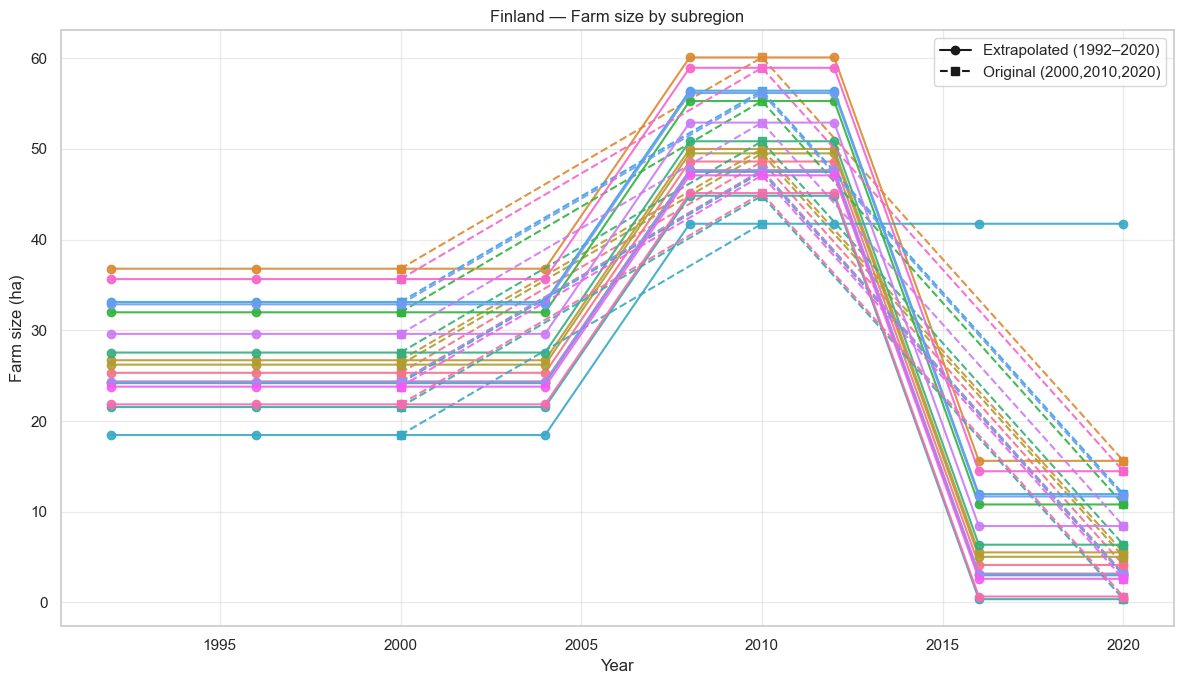

In [7]:
plotCountry('Finland')

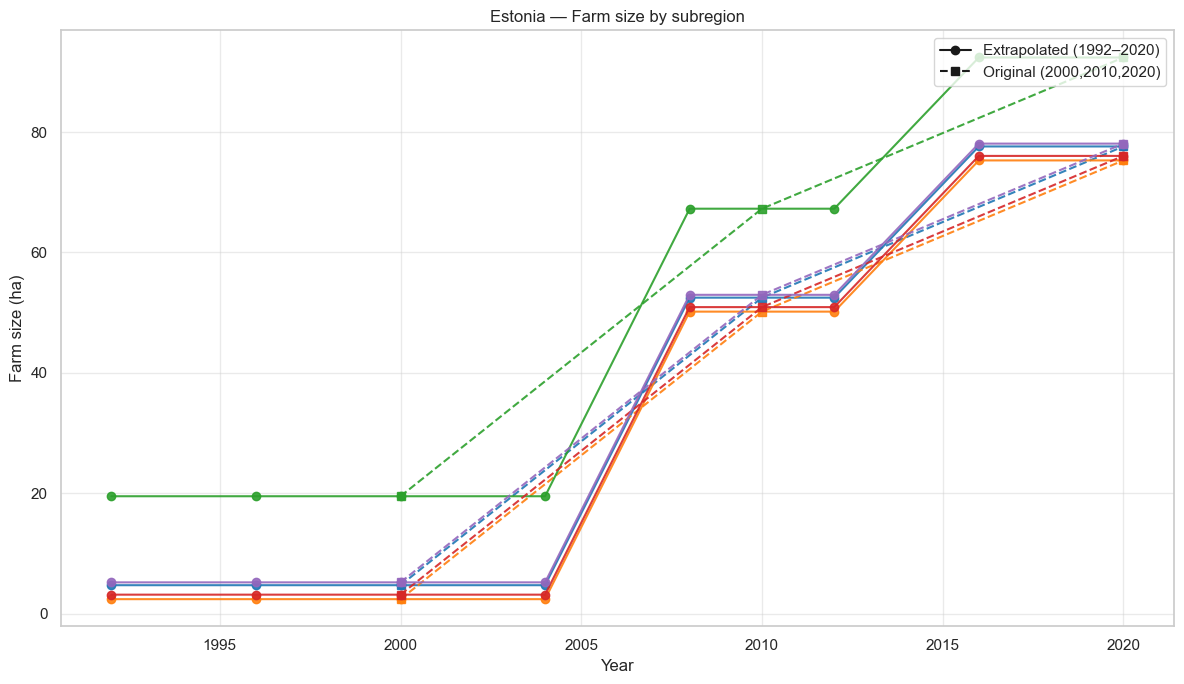

In [8]:
plotCountry('Estonia')

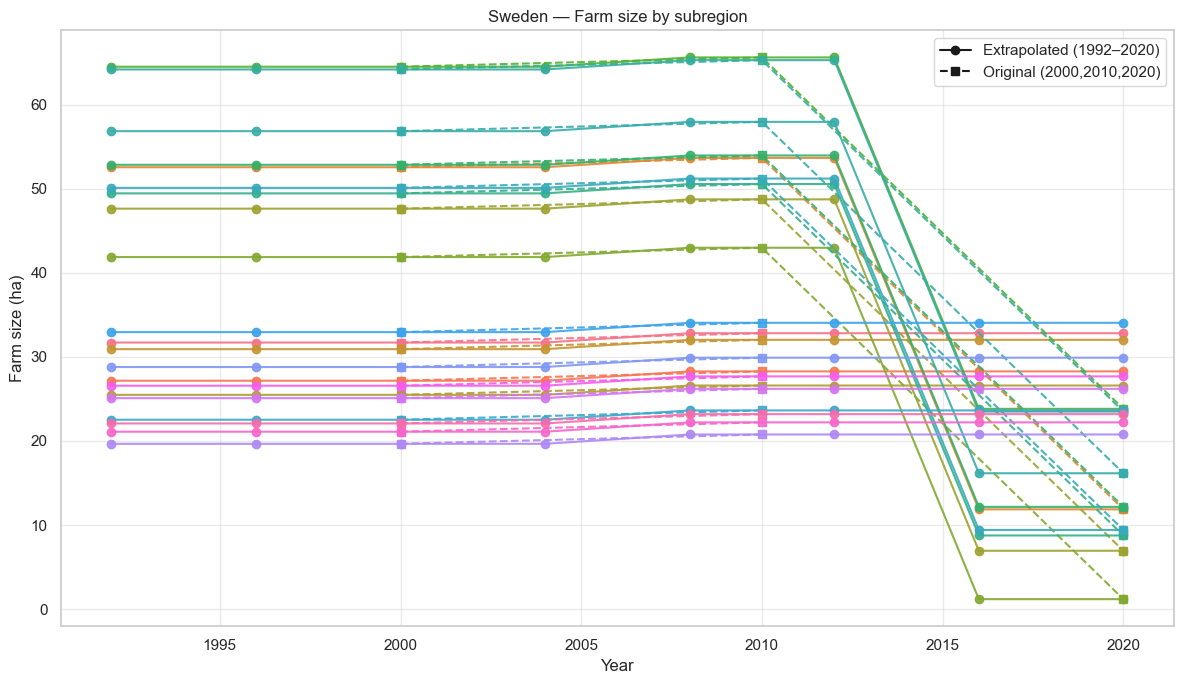

In [9]:
plotCountry('Sweden')

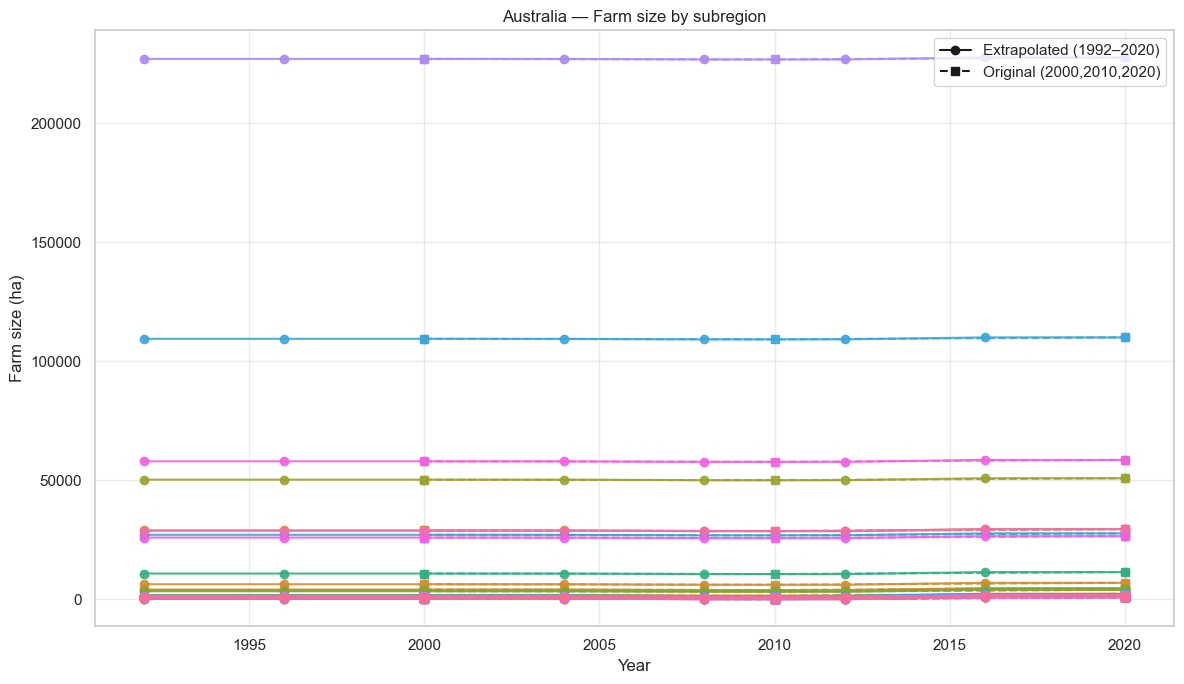

In [10]:
plotCountry('Australia')

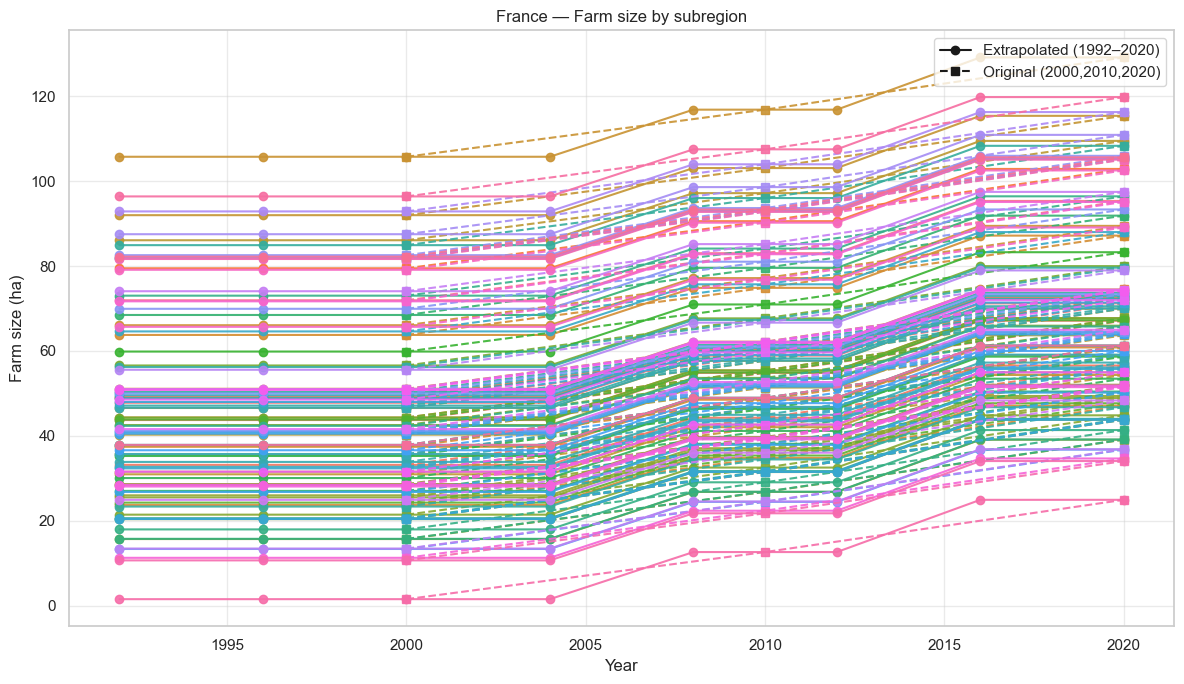

In [11]:
plotCountry('France')

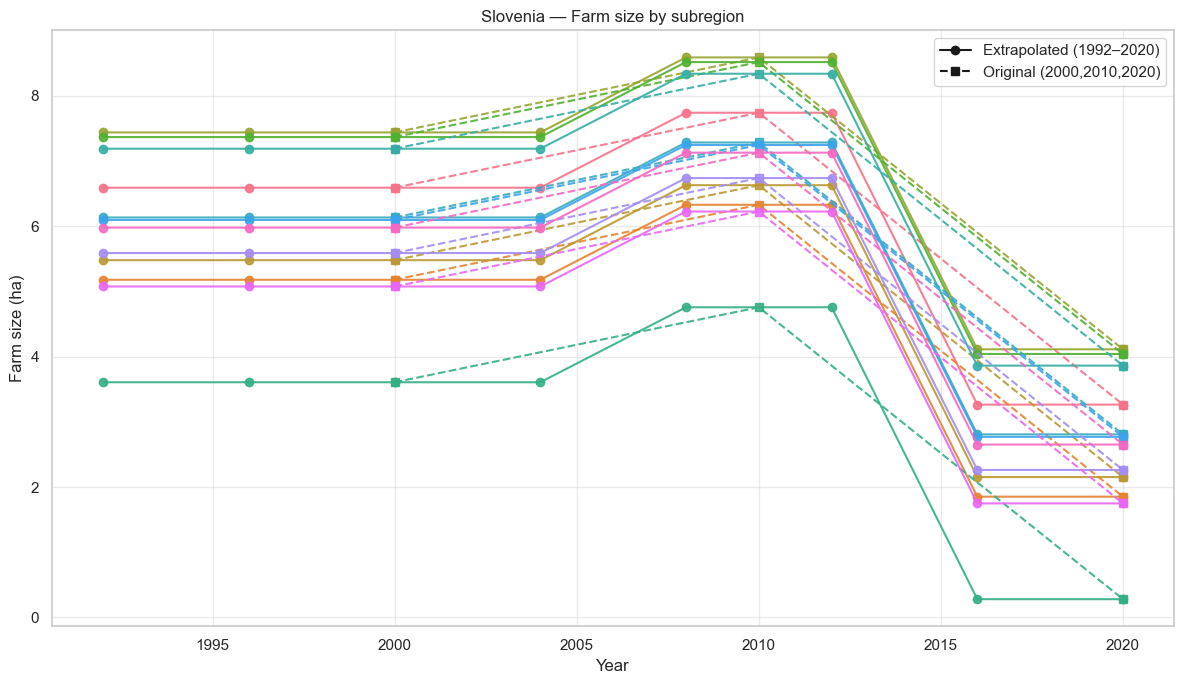

In [12]:
plotCountry('Slovenia')

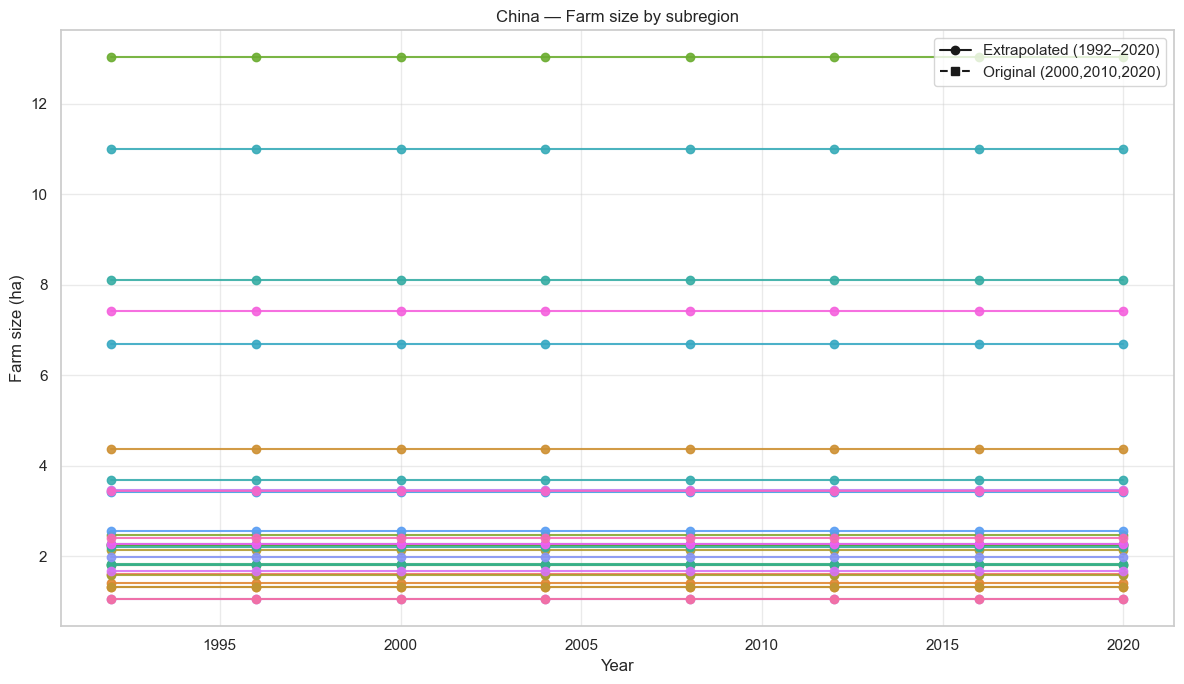

In [13]:
plotCountry('China')

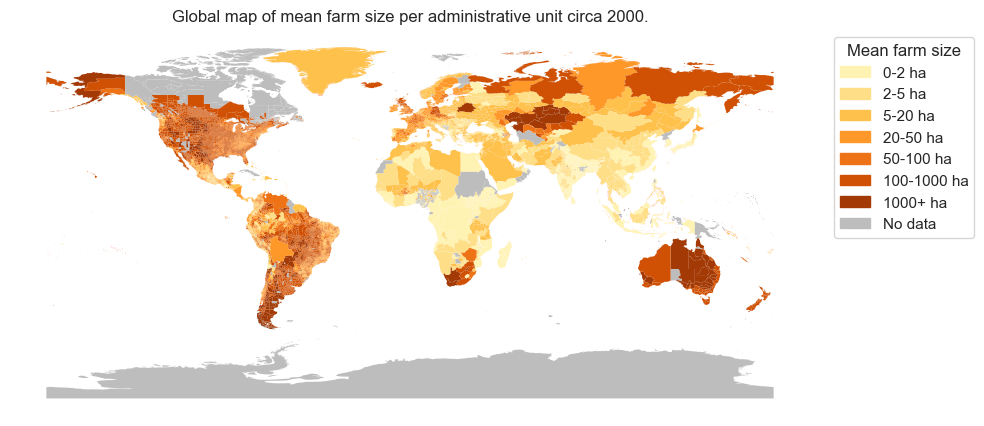

In [14]:


# bins, labels and colors
bins = [0, 2, 5, 20, 50, 100, 1000, np.inf]
labels = ['0-2 ha', '2-5 ha', '5-20 ha', '20-50 ha', '50-100 ha', '100-1000 ha', '1000+ ha']

# choose a 7-col sequential palette and convert to hex
#cmap = mpl.cm.get_cmap('YlOrBr')
cmap = mpl.colormaps.get_cmap('YlOrBr')   # or: cmap = mpl.colormaps['YlOrBr']

colors = [mpl.colors.to_hex(cmap(x)) for x in np.linspace(0.15, 0.85, len(labels))]
color_map = dict(zip(labels, colors))
nodata_color = '#bdbdbd'  # grey for no data

# make categorical column
gdf2_expanded['FARMSIZE_CAT'] = pd.cut(
    gdf2_expanded['FARMSIZE'],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=False
)

# convert to object, map to color hexes, then fill NaNs with grey
color_series = gdf2_expanded['FARMSIZE_CAT'].astype(object).map(color_map).fillna(nodata_color)

# plot
fig, ax = plt.subplots(figsize=(10, 7))
gdf2_expanded.plot(
    color=color_series,
    linewidth=0,
    edgecolor='white',
    ax=ax
)


# manual legend
patches = [mpatches.Patch(color=color_map[l], label=l) for l in labels] + [mpatches.Patch(color=nodata_color, label='No data')]
ax.legend(handles=patches, title='Mean farm size', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_title('Global map of mean farm size per administrative unit circa 2000.')
ax.set_axis_off()

fig.tight_layout()
out = '/Users/myliheik/Documents/myPython/sustainableFoodProduction/img/farmSize/farmSizecirca2000.png'
fig.savefig(out, dpi=300, bbox_inches="tight", transparent=True)


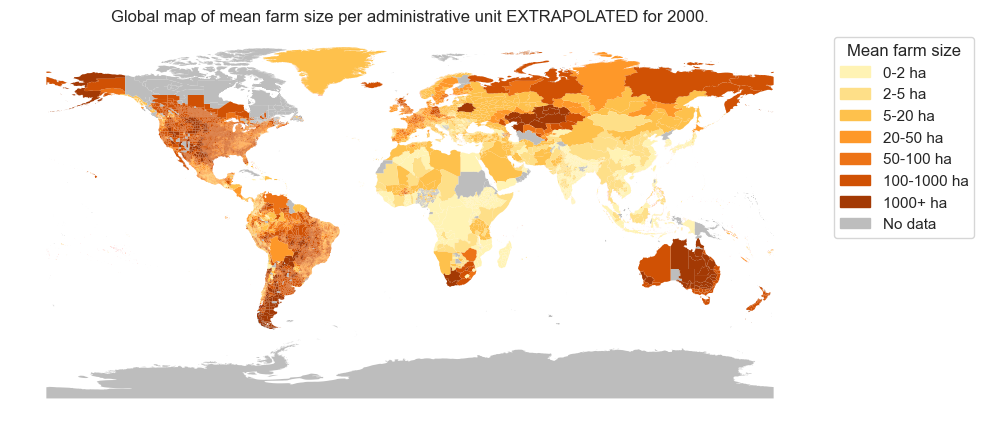

In [15]:

# make categorical column
gdf2_expanded['FARMSIZE_CAT'] = pd.cut(
    gdf2_expanded['EXPO_2000'],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=False
)

# convert to object, map to color hexes, then fill NaNs with grey
color_series = gdf2_expanded['FARMSIZE_CAT'].astype(object).map(color_map).fillna(nodata_color)

# plot
fig, ax = plt.subplots(figsize=(10, 7))
gdf2_expanded.plot(
    color=color_series,
    linewidth=0,
    edgecolor='white',
    ax=ax
)


# manual legend
patches = [mpatches.Patch(color=color_map[l], label=l) for l in labels] + [mpatches.Patch(color=nodata_color, label='No data')]
ax.legend(handles=patches, title='Mean farm size', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_title('Global map of mean farm size per administrative unit EXTRAPOLATED for 2000.')
ax.set_axis_off()

fig.tight_layout()
out = '/Users/myliheik/Documents/myPython/sustainableFoodProduction/img/farmSize/farmSizeEXPO_2000.png'
fig.savefig(out, dpi=300, bbox_inches="tight", transparent=True)


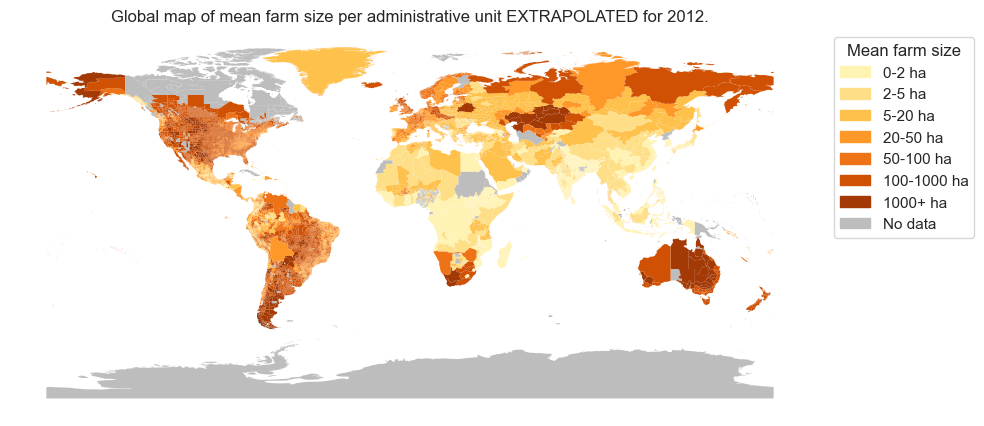

In [16]:

# make categorical column
gdf2_expanded['FARMSIZE_CAT'] = pd.cut(
    gdf2_expanded['EXPO_2012'],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=False
)

# convert to object, map to color hexes, then fill NaNs with grey
color_series = gdf2_expanded['FARMSIZE_CAT'].astype(object).map(color_map).fillna(nodata_color)

# plot
fig, ax = plt.subplots(figsize=(10, 7))
gdf2_expanded.plot(
    color=color_series,
    linewidth=0,
    edgecolor='white',
    ax=ax
)


# manual legend
patches = [mpatches.Patch(color=color_map[l], label=l) for l in labels] + [mpatches.Patch(color=nodata_color, label='No data')]
ax.legend(handles=patches, title='Mean farm size', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_title('Global map of mean farm size per administrative unit EXTRAPOLATED for 2012.')
ax.set_axis_off()

fig.tight_layout()
out = '/Users/myliheik/Documents/myPython/sustainableFoodProduction/img/farmSize/farmSizeEXPO_2012.png'
fig.savefig(out, dpi=300, bbox_inches="tight", transparent=True)


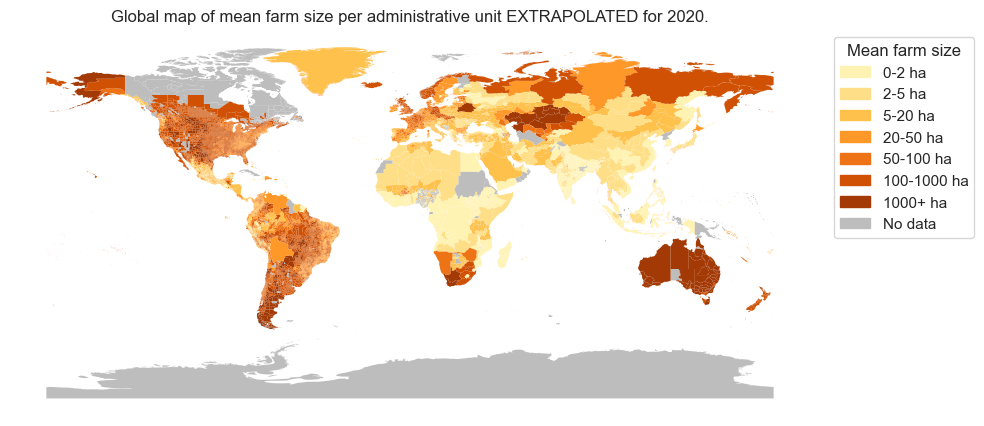

In [17]:

# make categorical column
gdf2_expanded['FARMSIZE_CAT'] = pd.cut(
    gdf2_expanded['EXPO_2020'],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=False
)

# convert to object, map to color hexes, then fill NaNs with grey
color_series = gdf2_expanded['FARMSIZE_CAT'].astype(object).map(color_map).fillna(nodata_color)

# plot
fig, ax = plt.subplots(figsize=(10, 7))
gdf2_expanded.plot(
    color=color_series,
    linewidth=0,
    edgecolor='white',
    ax=ax
)


# manual legend
patches = [mpatches.Patch(color=color_map[l], label=l) for l in labels] + [mpatches.Patch(color=nodata_color, label='No data')]
ax.legend(handles=patches, title='Mean farm size', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_title('Global map of mean farm size per administrative unit EXTRAPOLATED for 2020.')
ax.set_axis_off()

fig.tight_layout()
out = '/Users/myliheik/Documents/myPython/sustainableFoodProduction/img/farmSize/farmSizeEXPO_2020.png'
fig.savefig(out, dpi=300, bbox_inches="tight", transparent=True)
